In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
df = pd.read_csv('data/netflix_data.csv.zip')

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.shape

(8807, 12)

In [5]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [7]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [8]:
df['type'].value_counts(normalize=True) * 100

,proportion
type,
Movie,69.615079
TV Show,30.384921


In [9]:

print(f"Unique data in show_id  : {df['show_id'].unique()}")
print(f"Unique data in type : {df['type'].unique()}")
print(f"Unique data in  title : {df['title'].nunique()}")
print(f"Unique data in director : {df['director'].nunique()}")
print(f"Unique data in cast: {df['cast'].nunique()}")
print(f"Unique data in country : {df['country'].nunique()}")
print(f"Unique data in release_year : {df['release_year'].nunique()}")
print(f"Unique data in rating : {df['rating'].nunique()}")
print(f"Unique data in  duration : {df['duration'].nunique()}")
print(f"Unique data in  listed_in : {df['listed_in'].nunique()}")
print(f"Unique data in description : {df['description'].nunique()}")

Unique data in show_id  : ['s1' 's2' 's3' ... 's8805' 's8806' 's8807']
Unique data in type : ['Movie' 'TV Show']
Unique data in  title : 8807
Unique data in director : 4528
Unique data in cast: 7692
Unique data in country : 748
Unique data in release_year : 74
Unique data in rating : 17
Unique data in  duration : 220
Unique data in  listed_in : 514
Unique data in description : 8775


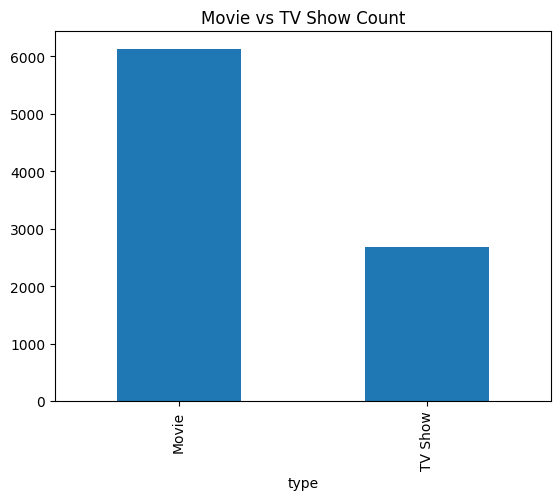

In [10]:
import matplotlib.pyplot as plt
df['type'].value_counts().plot(kind='bar', title='Movie vs TV Show Count')
plt.show()

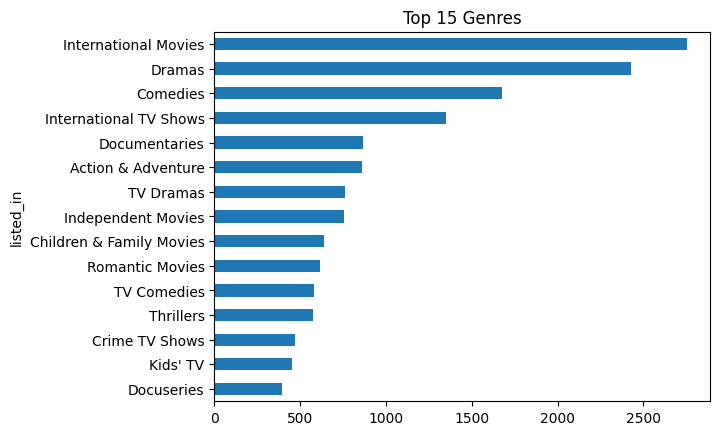

In [11]:
genres = df['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(15)
top_genres.plot(kind='barh', title='Top 15 Genres')
plt.gca().invert_yaxis()
plt.show()

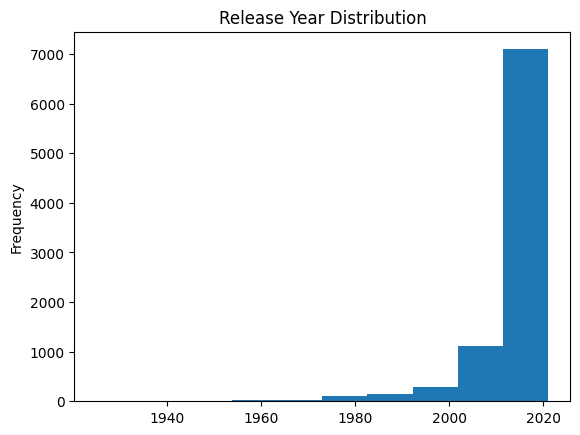

In [12]:
df['release_year'].plot(kind='hist', bins=10, title='Release Year Distribution')
plt.show()

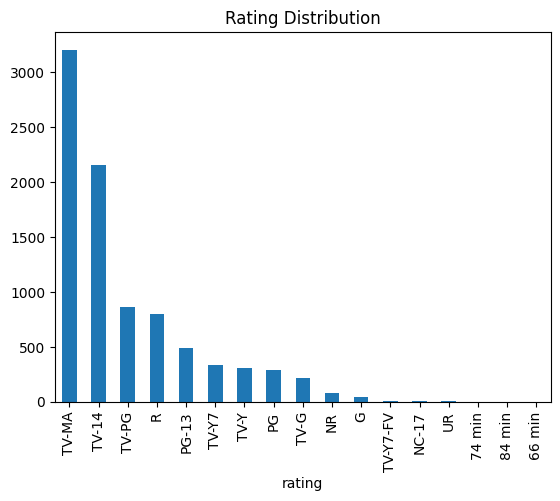

In [13]:
df['rating'].value_counts().plot(kind='bar', title='Rating Distribution')
plt.show()

In [14]:
countries = df['country'].str.split(', ').explode()
countries = countries[countries != '']
top_countries = countries.value_counts().head(10)
print(top_countries)

country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64


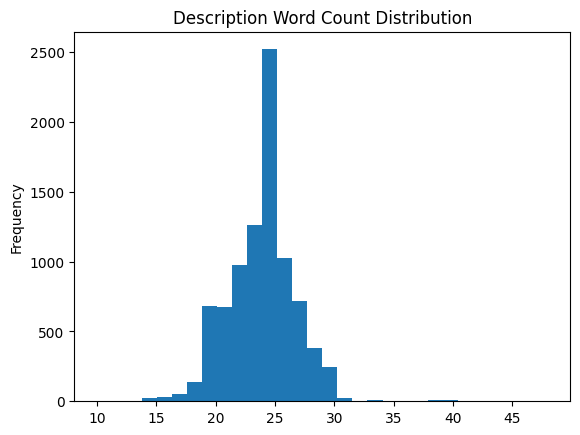

In [15]:
df['desc_length'] = df['description'].apply(lambda x: len(x.split()))
df['desc_length'].describe()
df['desc_length'].plot(kind='hist', bins=30, title='Description Word Count Distribution')
plt.show()

In [16]:
for col in ['director', 'cast', 'country']:
    df[col] = df[col].fillna('')

df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
df['duration'] = df['duration'].fillna(df['duration'].mode()[0])
df['date_added'] = df['date_added'].fillna('Unknown')

print(df.isnull().sum())

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
desc_length     0
dtype: int64


In [17]:
genre_type = df[['type','listed_in']].copy()
genre_type['listed_in'] = genre_type['listed_in'].str.split(', ')
genre_type = genre_type.explode('listed_in')
pd.crosstab(genre_type['listed_in'], genre_type['type']).sort_values('Movie', ascending=False).head(10)

type,Movie,TV Show
listed_in,,
International Movies,2752,0
Dramas,2427,0
Comedies,1674,0
Documentaries,869,0
Action & Adventure,859,0
Independent Movies,756,0
Children & Family Movies,641,0
Romantic Movies,616,0
Thrillers,577,0


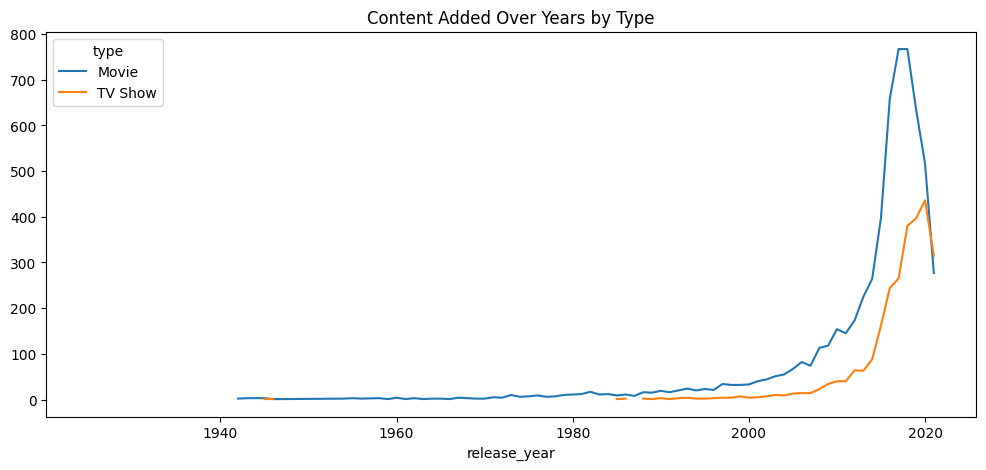

In [18]:
df.groupby(['release_year','type']).size().unstack().plot(figsize=(12,5), title='Content Added Over Years by Type')
plt.show()

In [19]:
def trim_cast(cast_str, n=3):
    if cast_str == '':
        return ''
    names = [x.strip() for x in cast_str.split(',')]
    return ' '.join(names[:n])

df['cast_trimmed'] = df['cast'].apply(trim_cast)

In [20]:
df.drop(columns=['cast', 'show_id'],inplace=True)

In [21]:
df.head()

,type,title,director,country,date_added,release_year,rating,duration,listed_in,description,desc_length,cast_trimmed
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",27,
1,TV Show,Blood & Water,,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",27,Ama Qamata Khosi Ngema Gail Mabalane
2,TV Show,Ganglands,Julien Leclercq,,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,27,Sami Bouajila Tracy Gotoas Samuel Jouy
3,TV Show,Jailbirds New Orleans,,,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",24,
4,TV Show,Kota Factory,,India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,24,Mayur More Jitendra Kumar Ranjan Raj


In [22]:
df['content'] = (
    df['title'] + ' ' +
    df['listed_in'] + ' ' +
    df['director'] + ' ' +
    df['cast_trimmed'] + ' ' +
    df['description']
)
df['content'] = df['content'].str.lower().str.strip()

print((df['content'].str.strip() == '').sum())
df[['title','content']].head(3)

0


,title,content
0,Dick Johnson Is Dead,dick johnson is dead documentaries kirsten joh...
1,Blood & Water,"blood & water international tv shows, tv drama..."
2,Ganglands,"ganglands crime tv shows, international tv sho..."


In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=10000,
    ngram_range=(1, 2)
)

tfidf_matrix = tfidf.fit_transform(df['content'])
print(tfidf_matrix.shape)

(8807, 10000)


In [24]:
tfidf_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print(tfidf_sim.shape)

(8807, 8807)


In [25]:
def recommend_by_movie(title, n=5):
    if title not in df['title'].values:
        return f"'{title}' dataset mein nahi mili."

    idx = df[df['title'] == title].index[0]
    sim_scores = list(enumerate(tfidf_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:n+1]

    movie_indices = [i[0] for i in sim_scores]
    scores = [round(i[1], 3) for i in sim_scores]

    result = df[['title','listed_in']].iloc[movie_indices].copy()
    result['similarity_score'] = scores
    return result

recommend_by_movie('adventure', n=5)

"'adventure' dataset mein nahi mili."

In [26]:
def recommend_by_query(query_text, n=5):
    query_vector = tfidf.transform([query_text.lower()])
    sim_scores = cosine_similarity(query_vector, tfidf_matrix)[0]

    sim_scores = list(enumerate(sim_scores))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[:n]

    movie_indices = [i[0] for i in sim_scores]
    scores = [round(i[1], 3) for i in sim_scores]

    result = df[['title','listed_in']].iloc[movie_indices].copy()
    result['similarity_score'] = scores
    return result

recommend_by_query("space adventure with robots and aliens", n=5)

,title,listed_in,similarity_score
2109,John Was Trying to Contact Aliens,"Documentaries, LGBTQ Movies",0.378
4893,Pocoyo & The Space Circus,Movies,0.289
1005,Keymon and Nani in Space Adventure,"Children & Family Movies, Comedies",0.279
71,A StoryBots Space Adventure,Children & Family Movies,0.239
419,Chhota Bheem: Bheem vs Aliens,"Children & Family Movies, Sports Movies",0.228


In [ ]:
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

model = SentenceTransformer('all-MiniLM-L6-v2')

sbert_embeddings = model.encode(
    df['content'].tolist(),
    show_progress_bar=True,
    convert_to_numpy=True
).astype(np.float32)

print("Embeddings shape:", sbert_embeddings.shape)

np.save('sbert_embeddings.npy', sbert_embeddings)

sbert_sim = cosine_similarity(sbert_embeddings, sbert_embeddings).astype(np.float32)
print("Similarity matrix shape:", sbert_sim.shape)


def recommend_by_movie_sbert(title, n=5):
    if title not in df['title'].values:
        return f"'{title}' not found"

    idx = df[df['title'] == title].index[0]
    sim_scores = list(enumerate(sbert_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:n+1]

    movie_indices = [i[0] for i in sim_scores]
    scores = [round(i[1], 3) for i in sim_scores]

    result = df[['title', 'listed_in']].iloc[movie_indices].copy()
    result['similarity_score'] = scores
    return result


def recommend_by_query_sbert(query_text, n=5):
    query_vector = model.encode([query_text], convert_to_numpy=True).astype(np.float32)
    sim_scores = cosine_similarity(query_vector, sbert_embeddings)[0]

    sim_scores = list(enumerate(sim_scores))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[:n]

    movie_indices = [i[0] for i in sim_scores]
    scores = [round(i[1], 3) for i in sim_scores]

    result = df[['title', 'listed_in']].iloc[movie_indices].copy()
    result['similarity_score'] = scores
    return result


print("\nSBERT - Movie Based Recommendation:")
print(recommend_by_movie_sbert('Inception', n=5))

print("\nSBERT - Text Query Recommendation:")
print(recommend_by_query_sbert("space adventure with robots and aliens", n=5))

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/276 [00:00<?, ?it/s]

Embeddings shape: (8807, 384)
Similarity matrix shape: (8807, 8807)

SBERT - Movie Based Recommendation:
          title                                          listed_in  \
7063   Incoming               Action & Adventure, Sci-Fi & Fantasy   
363   The Vault  Action & Adventure, International Movies, Thri...   
1536  Incarnate                           Horror Movies, Thrillers   
4812        TAU                        Sci-Fi & Fantasy, Thrillers   
8220    The Box                        Sci-Fi & Fantasy, Thrillers   

      similarity_score  
7063             0.561  
363              0.560  
1536             0.558  
4812             0.556  
8220             0.555  

SBERT - Text Query Recommendation:
                            title  \
71    A StoryBots Space Adventure   
5958                            9   
133                       Chappie   
5006                 Battle Drone   
7636                   Occupation   

                                              listed_in  similari